In [1]:
%pip install -q pandas numpy scikit-learn matplotlib joblib openpyxl


In [15]:
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

DATA_PATH = "/content/Integrated_Irish_Weather_2010_2024.xlsx"

# Load Excel
df = pd.read_excel(DATA_PATH)

# Normalize headers if needed
rename_map = {
    "date_time":"date","Date":"date","DATE":"date",
    "tmin":"tmin_c","tmax":"tmax_c","tmean":"tmean_c","temperature":"tmean_c",
    "rain":"rain_mm","rainfall":"rain_mm","precip_mm":"rain_mm",
    "humidity":"rh_pct","Humidity":"rh_pct",
    "county_name":"county","region":"county"
}
df = df.rename(columns={k:v for k,v in rename_map.items() if k in df.columns})
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df = df.dropna(subset=["date"]).sort_values("date").reset_index(drop=True)

# Convenience fills
if "tmean_c" not in df and {"tmin_c","tmax_c"}.issubset(df.columns):
    df["tmean_c"] = (df["tmin_c"] + df["tmax_c"]) / 2
if "latitude" not in df: df["latitude"] = 53.5
if "county" not in df:   df["county"] = "Ireland"  # single-group fallback

print(df.shape)
df.head()


(45094, 9)


,date,County,Temperature (°C),Rainfall (mm),Humidity (%),Wind Speed (km/h),Frequency,latitude,county
0,2010-01-01,Cork,14.8,0.0,69.1,13.7,Daily,53.5,Ireland
1,2010-01-01,Galway,5.5,1.0,88.3,1.9,Daily,53.5,Ireland
2,2010-01-01,Limerick,10.5,0.5,81.8,10.9,Daily,53.5,Ireland
3,2010-01-01,Mayo,9.8,1.1,87.4,15.6,Daily,53.5,Ireland
4,2010-01-01,Kerry,9.9,0.7,83.3,17.8,Daily,53.5,Ireland


Feature engineering

In [16]:
DEFAULT_KC = {1:0.9,2:0.9,3:0.95,4:1.0,5:1.05,6:1.1,7:1.1,8:1.05,9:1.0,10:0.95,11:0.92,12:0.9}
RAIN_W, ET0_W, TMAX_W = (3,7,14), (3,7,14), (7,)

def Ra_MJ(latitude, doy):
    phi = math.radians(latitude)
    dr = 1 + 0.033*math.cos(2*math.pi*doy/365)
    delta = 0.409*math.sin(2*math.pi*doy/365 - 1.39)
    ws = math.acos(-math.tan(phi)*math.tan(delta))
    Gsc=0.0820
    return max((24*60/math.pi)*Gsc*dr*(ws*math.sin(phi)*math.sin(delta)+
                math.cos(phi)*math.cos(delta)*math.sin(ws)), 0.0)

def et0_hs(tmean,RaMJ):
    Ra_mm = RaMJ/2.45
    # The original Hargreaves-Samani equation uses Tmax and Tmin difference,
    # but we only have Tmean here, so we simplify by removing Td
    return max(0.0023 * Ra_mm * (tmean + 17.8), 0.0) # Removed sqrt(td)

def pe_daily(rain):  # effective rainfall heuristic
    return min(0.7*max(rain,0.0), max(rain,0.0))

def build_features(weather: pd.DataFrame) -> pd.DataFrame:
    df = weather.copy()
    df = df.rename(columns={"Temperature (°C)": "tmean_c", "Rainfall (mm)": "rain_mm", "Humidity (%)":"rh_pct"}) # Add renaming for relevant columns if not done in the first cell
    df["month"] = df["date"].dt.month
    df["doy"]   = df["date"].dt.dayofyear
    df["Ra"]    = [Ra_MJ(lat, doy) for lat, doy in zip(df["latitude"], df["doy"])]
    # Use only tmean_c for et0_hs
    df["et0_mm"]= [et0_hs(c,r) for c,r in zip(df.tmean_c, df.Ra)]
    df["kc"]    = df["month"].map(DEFAULT_KC)
    df["etc_mm"]= df["et0_mm"] * df["kc"]
    df["pe_mm"] = df["rain_mm"].apply(pe_daily)
    df["nir_mm"]= (df["etc_mm"] - df["pe_mm"]).clip(lower=0)

    parts=[]
    for c, g in df.groupby("county"):
        g = g.sort_values("date").copy()
        for w in RAIN_W: g[f"rain_sum_{w}d"] = g["rain_mm"].rolling(w, min_periods=1).sum()
        for w in ET0_W:  g[f"et0_sum_{w}d"]  = g["et0_mm"].rolling(w, min_periods=1).sum()
        # Removed TMAX_W loop as tmax is not available
        parts.append(g)
    df = pd.concat(parts, axis=0)
    df["awc_mm"] = 100.0  # default soil water capacity
    return df

features = build_features(df)
features.to_parquet("features.parquet", index=False)
features.head()

,date,County,tmean_c,rain_mm,rh_pct,Wind Speed (km/h),Frequency,latitude,county,month,...,etc_mm,pe_mm,nir_mm,rain_sum_3d,rain_sum_7d,rain_sum_14d,et0_sum_3d,et0_sum_7d,et0_sum_14d,awc_mm
0,2010-01-01,Cork,14.8,0.0,69.1,13.7,Daily,53.5,Ireland,1,...,0.157617,0.00,0.157617,0.0,0.0,0.0,0.175130,0.175130,0.175130,100.0
13,2010-01-01,Dublin,0.4,0.7,61.5,15.9,Daily,53.5,Ireland,1,...,0.087995,0.49,0.000000,0.7,0.7,0.7,0.272902,0.272902,0.272902,100.0
12,2010-01-01,Waterford,9.5,1.1,72.9,13.8,Monthly,53.5,Ireland,1,...,0.131992,0.77,0.000000,1.8,1.8,1.8,0.419560,0.419560,0.419560,100.0
10,2010-01-01,Mayo,15.3,2.9,86.6,16.4,Monthly,53.5,Ireland,1,...,0.160034,2.03,0.000000,4.7,4.7,4.7,0.422246,0.597375,0.597375,100.0
9,2010-01-01,Limerick,13.5,0.8,85.7,21.0,Monthly,53.5,Ireland,1,...,0.151332,0.56,0.000000,4.8,5.5,5.5,0.492620,0.765522,0.765522,100.0


Time-aware split

In [17]:
TRAIN_END = "2019-12-31"
VALID_END = "2022-12-31"

train_end = pd.to_datetime(TRAIN_END)
valid_end = pd.to_datetime(VALID_END)

train_df = features[features["date"] <= train_end].copy()
valid_df = features[(features["date"] > train_end) & (features["date"] <= valid_end)].copy()
test_df  = features[features["date"] > valid_end].copy()

print("[SPLIT]")
print("Train:", train_df["date"].min().date(), "→", train_df["date"].max().date(), f"({len(train_df):,})")
if len(valid_df):
    print("Valid:", valid_df["date"].min().date(), "→", valid_df["date"].max().date(), f"({len(valid_df):,})")
if len(test_df):
    print("Test :", test_df["date"].min().date(),  "→", test_df["date"].max().date(),  f"({len(test_df):,})")


[SPLIT]
Train: 2010-01-01 → 2019-12-31 (30,058)
Valid: 2020-01-01 → 2022-12-31 (9,016)
Test : 2023-01-01 → 2024-12-31 (6,020)


Train model

In [18]:
from sklearn.ensemble import RandomForestRegressor
import joblib

FEATURES_COLS = [
    "tmin_c","tmax_c","tmean_c","rain_mm","rh_pct","wind_ms","solar_mj_m2_day",
    "et0_mm","kc","etc_mm","pe_mm",
    "rain_sum_3d","rain_sum_7d","rain_sum_14d",
    "et0_sum_3d","et0_sum_7d","et0_sum_14d",
    "tmax_mean_7d","awc_mm"
]
TARGET = "nir_mm"

def safe_cols(df, cols): return [c for c in cols if c in df.columns]

Xtr, ytr = train_df[safe_cols(train_df, FEATURES_COLS)], train_df[TARGET].values
Xva, yva = (valid_df[safe_cols(valid_df, FEATURES_COLS)], valid_df[TARGET].values) if len(valid_df) \
           else (train_df[safe_cols(train_df, FEATURES_COLS)].tail(90), train_df[TARGET].tail(90).values)

rf = RandomForestRegressor(n_estimators=500, min_samples_leaf=3, random_state=42, n_jobs=-1)
rf.fit(Xtr, ytr)
joblib.dump(rf, "model_rf.pkl")

print("RandomForest trained → model_rf.pkl")


RandomForest trained → model_rf.pkl


Results (metrics: MAE, RMSE, R²)

In [7]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def metrics(y,p):
    mse = mean_squared_error(y,p)
    return {"MAE":mean_absolute_error(y,p),
            "RMSE":float(np.sqrt(mse)),
            "R2":r2_score(y,p)}

lines = []

# VALID
pv = rf.predict(Xva)
mv = metrics(yva, pv)
lines.append(f"[RF] VALID  MAE={mv['MAE']:.3f}  RMSE={mv['RMSE']:.3f}  R2={mv['R2']:.3f}")

# TEST
if len(test_df):
    Xt, yt = test_df[safe_cols(test_df, FEATURES_COLS)], test_df[TARGET].values
    pt = rf.predict(Xt)
    mt = metrics(yt, pt)
    lines.append(f"[RF] TEST   MAE={mt['MAE']:.3f}  RMSE={mt['RMSE']:.3f}  R2={mt['R2']:.3f}")

print("\n".join(lines))
with open("metrics.txt","w") as f: f.write("\n".join(lines))


[RF] VALID  MAE=0.001  RMSE=0.006  R2=1.000
[RF] TEST   MAE=0.001  RMSE=0.003  R2=1.000


Feature importance

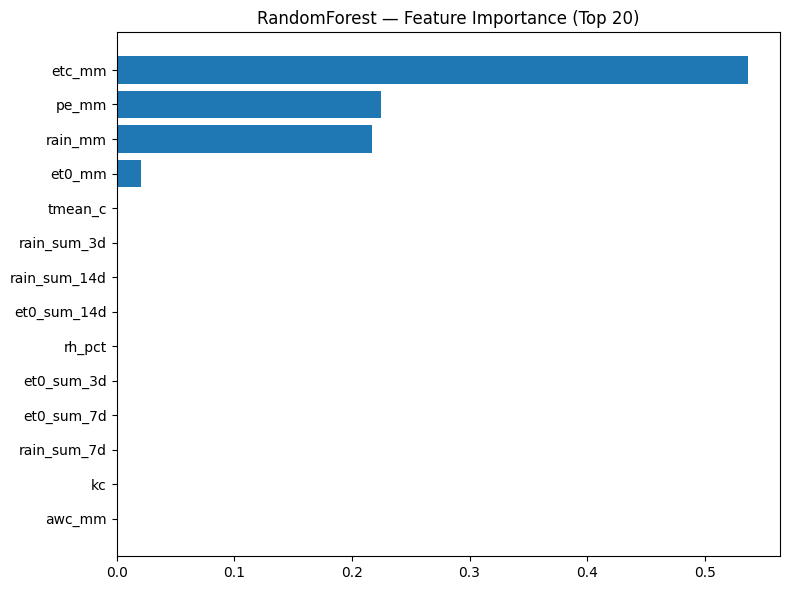

Saved: rf_feature_importance.png


In [8]:
order = np.argsort(rf.feature_importances_)[::-1]
names = np.array(safe_cols(train_df, FEATURES_COLS))[order][:20]
vals  = rf.feature_importances_[order][:20]

plt.figure(figsize=(8,6))
plt.barh(names[::-1], vals[::-1])
plt.title("RandomForest — Feature Importance (Top 20)")
plt.tight_layout()
plt.savefig("rf_feature_importance.png", dpi=200)
plt.show()

print("Saved: rf_feature_importance.png")


Predict next-day NIR per county

In [10]:
latest = features.sort_values(["county","date"]).groupby("county").tail(1).copy()
X_latest = latest[safe_cols(latest, FEATURES_COLS)]
preds = rf.predict(X_latest)

pred_df = latest[["county","date"]].copy()
pred_df["model"] = "rf"
pred_df["pred_nir_mm_nextday"] = preds
display(pred_df)

pred_df.to_csv("sample_predictions.csv", index=False)
print("Saved: sample_predictions.csv")


,county,date,model,pred_nir_mm_nextday
45093,Ireland,2024-12-31,rf,0.0


Saved: sample_predictions.csv
